Cell 1 — Imports & Setup (Code Cell)

In [116]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

Cell 2 — Load + Clean Data (Code Cell)
## 1. Data Loading and Preprocessing

In [117]:
# Load CSV
df = pd.read_csv('gym_members_exercise_tracking.csv')
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


2. Quick exploratory plots (on the raw data)

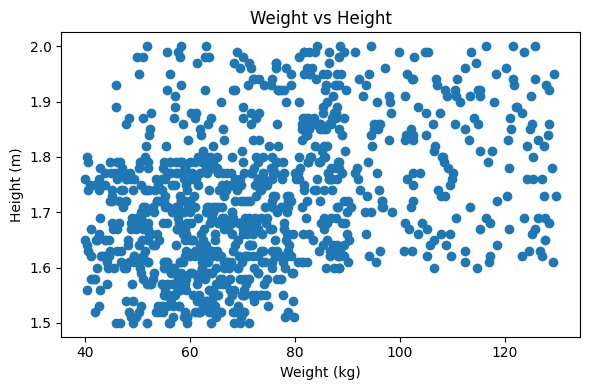

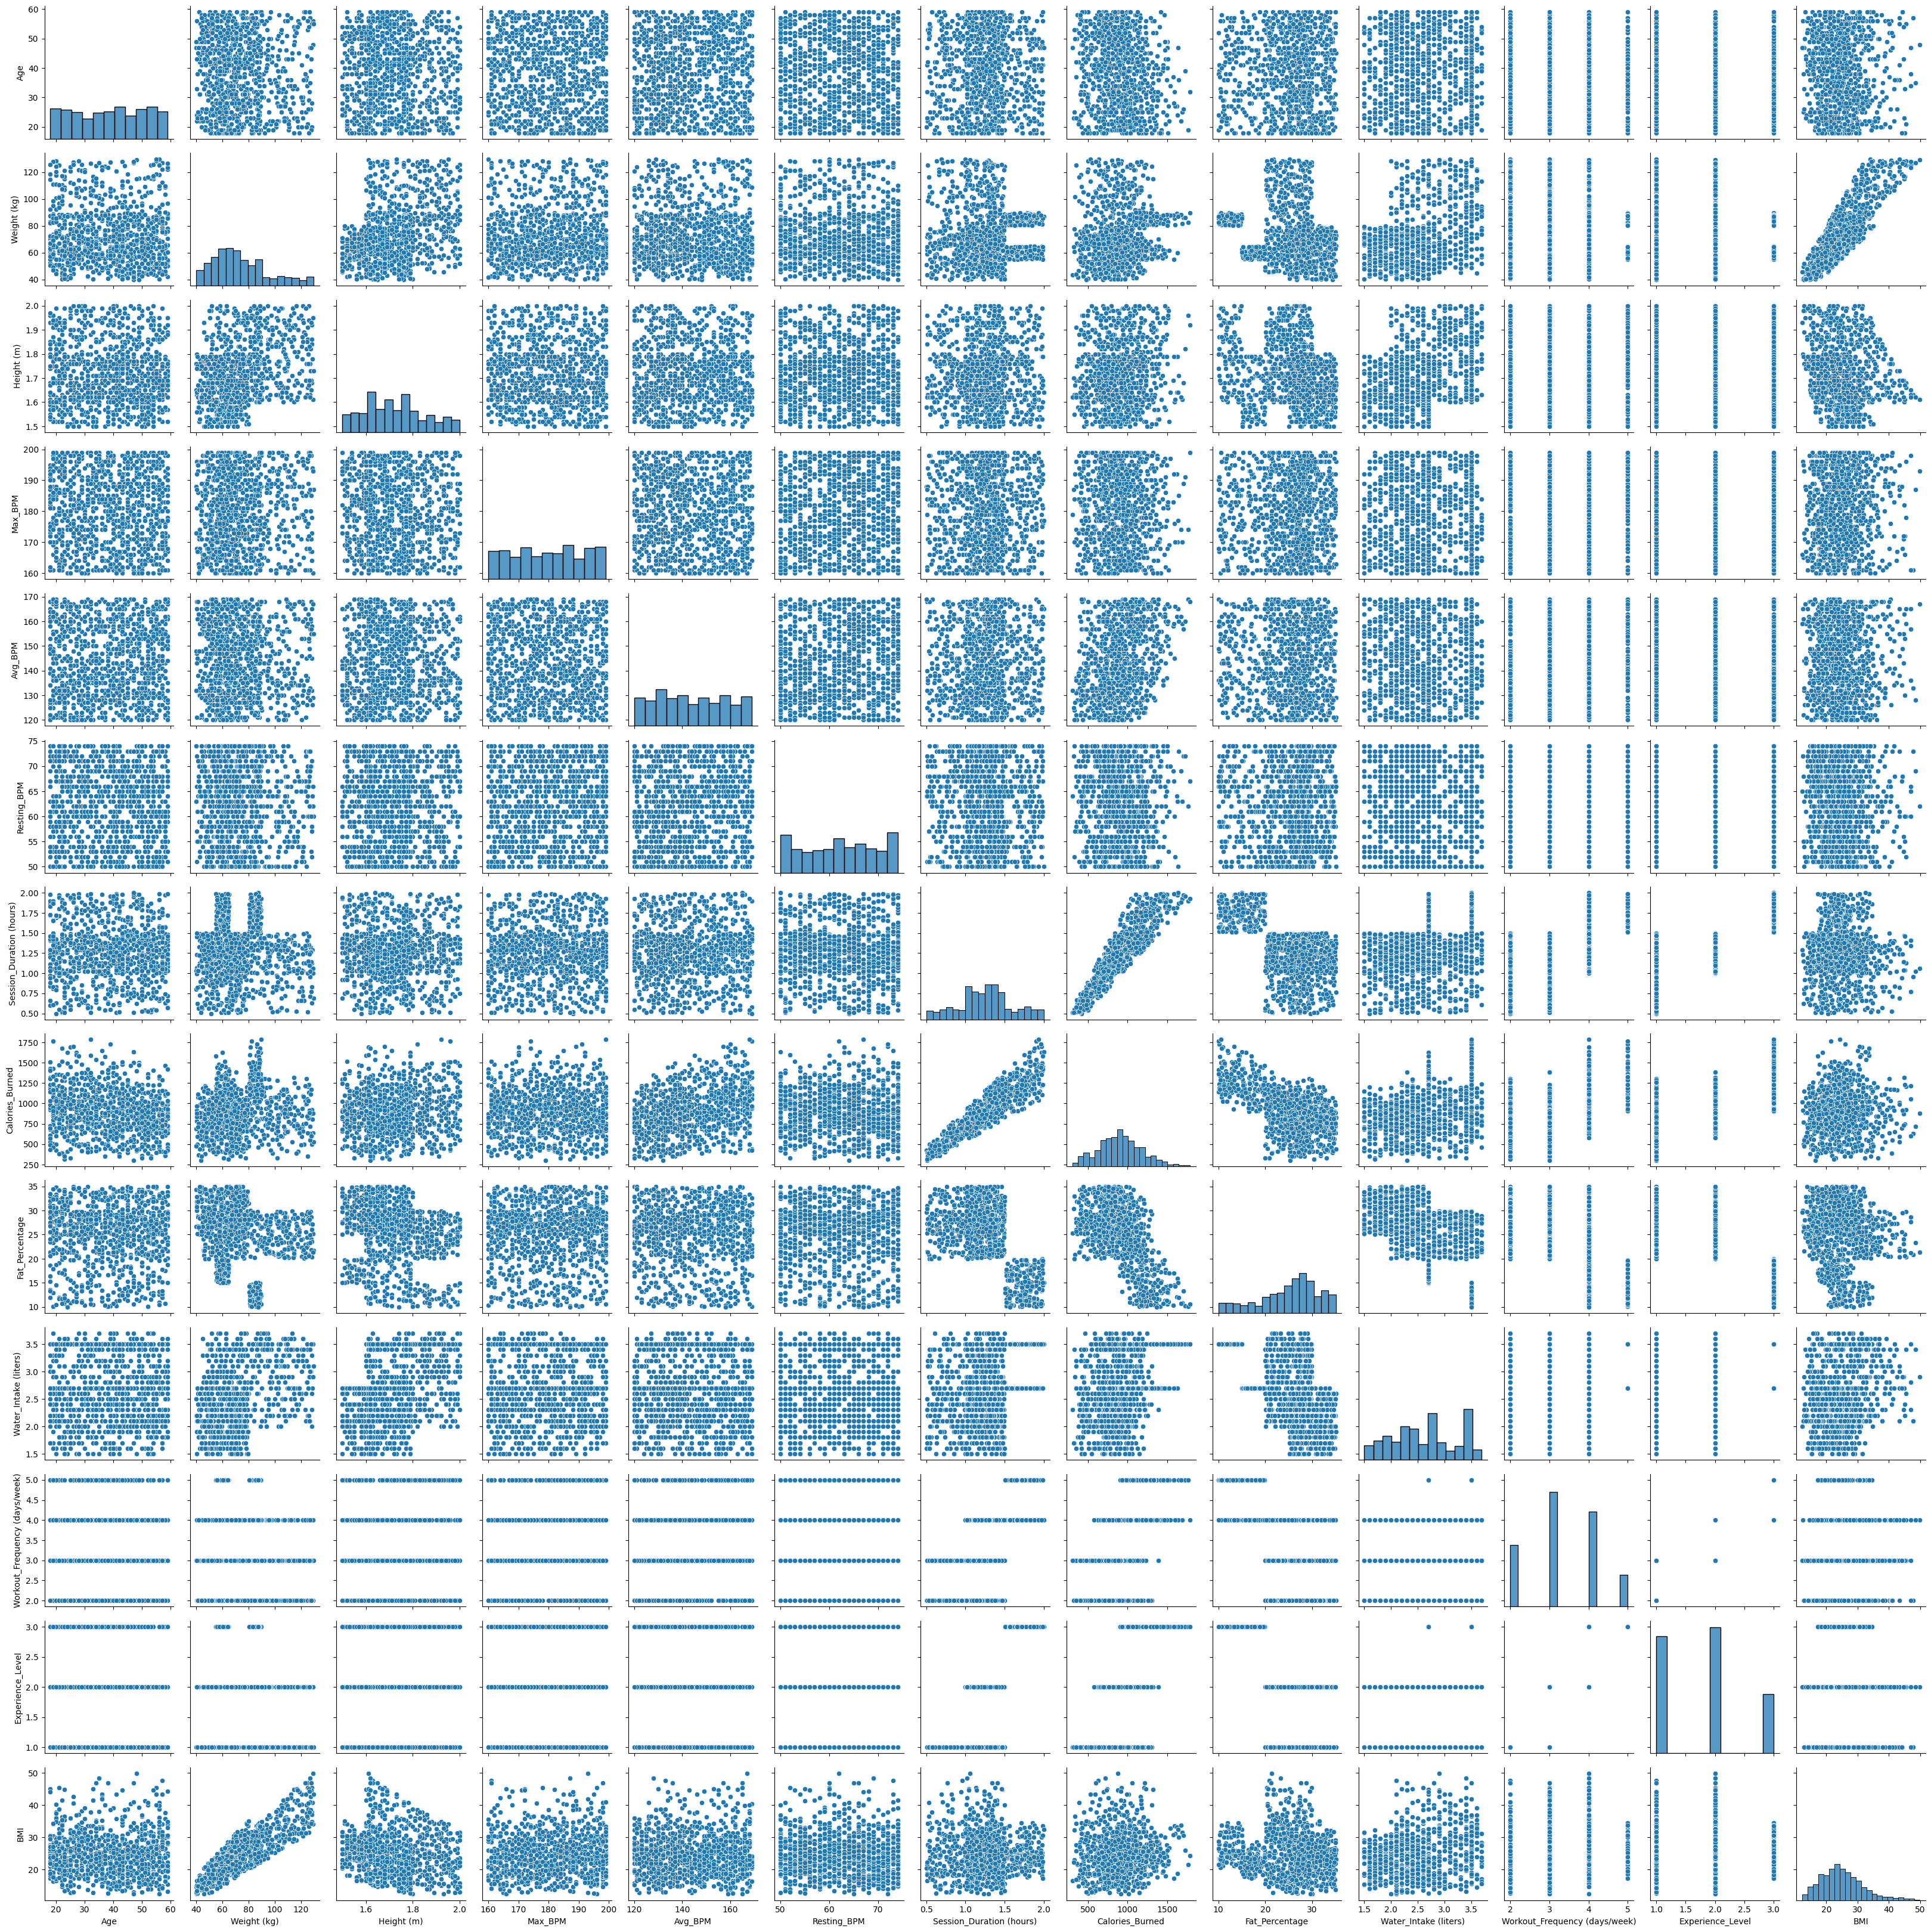

In [118]:
# 2.1 Weight vs Height joint plot
plt.figure(figsize=(6, 4))
plt.scatter(df['Weight (kg)'], df['Height (m)'])
plt.title('Weight vs Height')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (m)')
plt.tight_layout()
plt.show()

# 2.2 Pairplot of numeric features for visual inspection
numeric_cols = df.select_dtypes(include=['number']).columns
df_explore = df[numeric_cols]

sns.pairplot(df_explore, height=2.5)
plt.tight_layout()
plt.show()

3.Handle missing values (on full dataframe)

In [119]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

# Numeric: fill with column means
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical: fill with most frequent value (mode)
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


4. Feature Engineering

In [120]:
# Feature Engineering
df['Workout_Intensity'] = df['Avg_BPM'] / df['Resting_BPM']

 5. Drop features based on pairplot inspection
   - low/no relationship with target (Calories_Burned)
   - or redundant because BMI already encodes height/weight

In [121]:
drop_from_pairplot = [
    'Age',
    'Resting_BPM',
    'Water_Intake (liters)',
    'Workout_Frequency (days/week)',
    'Fat_Percentage',
    'Weight (kg)',
    'Height (m)'
]

# Only drop columns that actually exist (defensive)
drop_from_pairplot = [c for c in drop_from_pairplot if c in df.columns]

df_reduced = df.drop(columns=drop_from_pairplot)
print("After dropping low-value / redundant features:\n", df_reduced.columns, "\n")

After dropping low-value / redundant features:
 Index(['Gender', 'Max_BPM', 'Avg_BPM', 'Session_Duration (hours)',
       'Calories_Burned', 'Workout_Type', 'Experience_Level', 'BMI',
       'Workout_Intensity'],
      dtype='object') 



 6. Correlation matrix on numeric features ONLY
    (temporarily drop categorical variables)

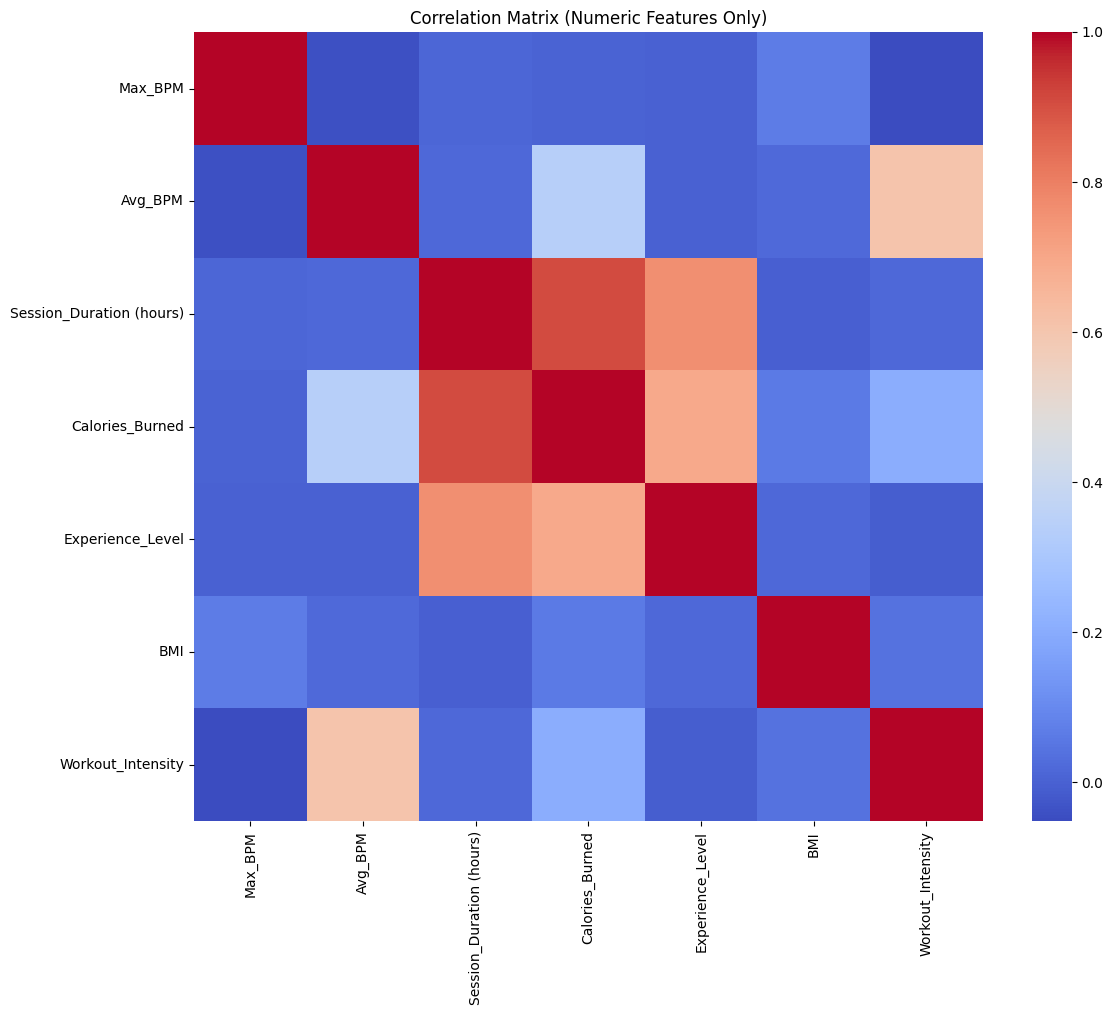

In [122]:
df_corr = df_reduced.drop(columns=['Gender', 'Workout_Type'])

plt.figure(figsize=(12, 10))
corr_matrix = df_corr.corr()
sns.heatmap(
    corr_matrix,
    cbar=True,
    annot=False,
    square=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix (Numeric Features Only)")
plt.tight_layout()
plt.show()

 7. Final modelling dataframe:
 - ensure Experience_Level is numeric
 - one-hot encode categorical variables

In [123]:
df_model = df_reduced.copy()

# If Experience_Level is categorical/ordinal, cast to float
df_model['Experience_Level'] = df_model['Experience_Level'].astype(float)

# One-hot encode Gender and Workout_Type
df_model = pd.get_dummies(df_model, columns=['Gender', 'Workout_Type'])

# This is the final dataset you’ll feed into Linear/Ridge/LASSO/MLP
df_model.head()
print("Final modelling columns:\n", df_model.columns)

Final modelling columns:
 Index(['Max_BPM', 'Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Experience_Level', 'BMI', 'Workout_Intensity', 'Gender_Female',
       'Gender_Male', 'Workout_Type_Cardio', 'Workout_Type_HIIT',
       'Workout_Type_Strength', 'Workout_Type_Yoga'],
      dtype='object')


8.Train/Test Split and Scaling

In [124]:
target = 'Calories_Burned'

X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


9.MLP Model Definition

In [125]:
# Device and tensor conversion
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1).to(device)

# Model definition
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.layers(x)

input_dim = X_train.shape[1]
model = MLP(input_dim).to(device)

# Training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
batch_size = 32
epochs = 100

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Lists for plotting
train_losses = []


# Training loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    # Average loss this epoch
    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)



    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} ")



Epoch [1/100] - Loss: 888746.0109 
Epoch [2/100] - Loss: 885546.6790 
Epoch [3/100] - Loss: 873666.3382 
Epoch [4/100] - Loss: 838878.4073 
Epoch [5/100] - Loss: 756338.2039 
Epoch [6/100] - Loss: 596901.3302 
Epoch [7/100] - Loss: 365091.6328 
Epoch [8/100] - Loss: 137639.2616 
Epoch [9/100] - Loss: 31759.6741 
Epoch [10/100] - Loss: 18305.0973 
Epoch [11/100] - Loss: 15007.9616 
Epoch [12/100] - Loss: 13368.5372 
Epoch [13/100] - Loss: 12094.2639 
Epoch [14/100] - Loss: 11121.2229 
Epoch [15/100] - Loss: 10297.3147 
Epoch [16/100] - Loss: 9543.6182 
Epoch [17/100] - Loss: 8931.3520 
Epoch [18/100] - Loss: 8339.0540 
Epoch [19/100] - Loss: 7825.4777 
Epoch [20/100] - Loss: 7379.1828 
Epoch [21/100] - Loss: 7001.2630 
Epoch [22/100] - Loss: 6624.6250 
Epoch [23/100] - Loss: 6311.9652 
Epoch [24/100] - Loss: 6027.7891 
Epoch [25/100] - Loss: 5794.5128 
Epoch [26/100] - Loss: 5510.5514 
Epoch [27/100] - Loss: 5292.1630 
Epoch [28/100] - Loss: 5089.5713 
Epoch [29/100] - Loss: 4937.3905 


9.Plot Epoch Loss

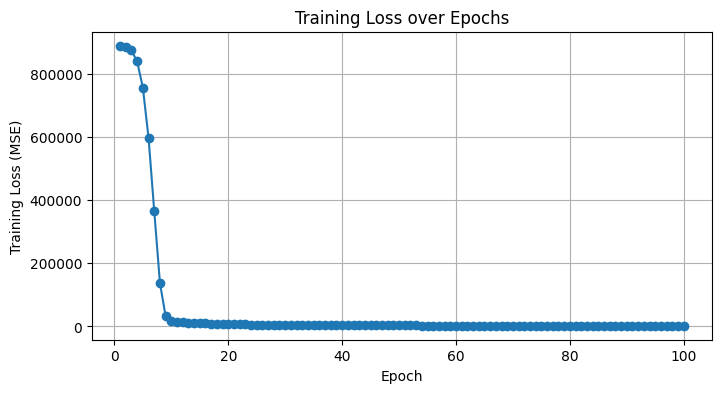

In [126]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()





10.valuation (Code Cell)


In [127]:
# Evaluation on test set
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).cpu().numpy().flatten()
    y_true = y_test_tensor.cpu().numpy().flatten()

mse = mean_squared_error(y_true, predictions)
r2 = r2_score(y_true, predictions)

print(f"MSE: {mse}")
print(f"R2: {r2}")





MSE: 3540.05322265625
R2: 0.9575660228729248
